# PageRank

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Макрушин С.В. "Случайные блуждания на графах"
* Документация:
    * https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.link_analysis.pagerank_alg.pagerank.html
    * https://networkx.org/documentation/stable/reference/algorithms/centrality.html
    * https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html

In [11]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

## Вопросы для совместного обсуждения

1\. Обсудите принцип работы алгоритма PageRank и подходы к его реализации.

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Загрузите граф карате-клуба. Воспользовавшийся реализаций алгоритма PageRank из `networkx`, вычислите важность каждого узла в сети. Визуализируйте граф, отмасшабировав размер каждого узла пропорционально полученным значениям.

- [ ] Проверено на семинаре

In [12]:
G = nx.karate_club_graph()
print("Граф карате-клуба загружен.")
print(f"Количество узлов: {G.number_of_nodes()}")
print(f"Количество ребер: {G.number_of_edges()}")

Граф карате-клуба загружен.
Количество узлов: 34
Количество ребер: 78



PageRank значения (первые 5 узлов):
  Узел 0: 0.0885
  Узел 1: 0.0574
  Узел 2: 0.0628
  Узел 3: 0.0372
  Узел 4: 0.0205


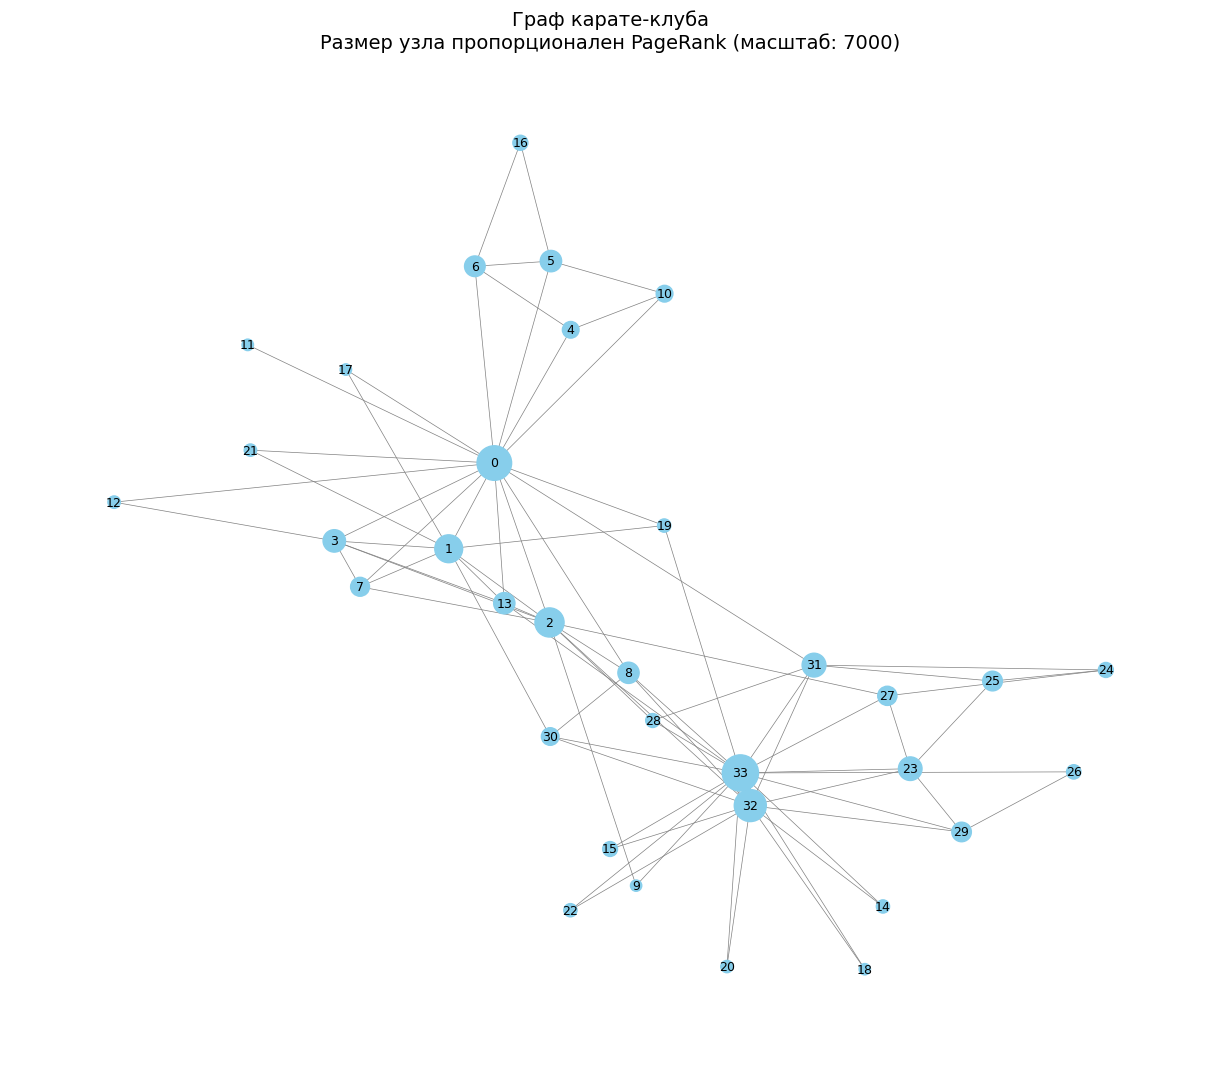

In [13]:
# Шаг 2: Вычисление PageRank 
# Используем параметры по умолчанию (alpha=0.85)
pagerank_scores = nx.pagerank(G)

print("\nPageRank значения (первые 5 узлов):")
for node_id in list(G.nodes())[:5]:
     print(f"  Узел {node_id}: {pagerank_scores[node_id]:.4f}")

# --- Шаг 3: Визуализация графа с масштабированием узлов ---
pos = nx.spring_layout(G, seed=42)

pr_values = [pagerank_scores[node] for node in G.nodes()]

scaling_factor = 7000 
node_sizes = [value * scaling_factor for value in pr_values]

plt.figure(figsize=(12, 10)) 

nx.draw(
    G,
    pos,
    with_labels=True,     # Показать номера узлов
    node_size=node_sizes, # Задать размеры узлов на основе PageRank
    node_color='skyblue', # Цвет узлов
    edge_color='gray',    # Цвет ребер
    font_size=9,          # Размер шрифта для номеров узлов
    width=0.5             # Толщина линий ребер
)

plt.title(f"Граф карате-клуба\nРазмер узла пропорционален PageRank (масштаб: {scaling_factor})", fontsize=14)
plt.show()


<p class="task" id="2"></p>

2\. Постройте несколько визуализаций графа в виде сетки, используя другие меры центральности: 
- центральность по степени;
- центральность по посредничеству;
- центральность по близости;
- центральность по собственному вектору;
- центральность по PageRank.

На каждом рисунке сделайте размеры узлов пропорционально соответствующей мере центральности. Сравните результаты и сделайте выводы.

- [ ] Проверено на семинаре

In [14]:
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
closeness_centrality = nx.closeness_centrality(G)
# Для eigenvector_centrality может потребоваться увеличить max_iter, если не сходится
try:
    eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000, tol=1e-06)
except nx.PowerIterationFailedConvergence:
    print("Предупреждение: Eigenvector centrality не сошлась за 1000 итераций.")
    # Попробуем с большим числом итераций или другой tol
    try:
        eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=5000, tol=1e-07)
        print("Eigenvector centrality сошлась с большим числом итераций.")
    except nx.PowerIterationFailedConvergence:
         print("Eigenvector centrality все равно не сошлась. Используем приближенные значения.")
         # В крайнем случае, можно использовать результат последней итерации,
         # который возвращается даже при ошибке, но это менее надежно.
         eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000, tol=1e-06, weight=None)


In [15]:
pagerank_centrality = nx.pagerank(G) # alpha=0.85 по умолчанию
print("Меры центральности рассчитаны.")

Меры центральности рассчитаны.


In [16]:
# Список центральностей и их названий для итерации
centralities = [
    degree_centrality,
    betweenness_centrality,
    closeness_centrality,
    eigenvector_centrality,
    pagerank_centrality
]
centrality_names = [
    'Степень (Degree)',
    'Посредничество (Betweenness)',
    'Близость (Closeness)',
    'Собственный вектор (Eigenvector)',
    'PageRank'
]

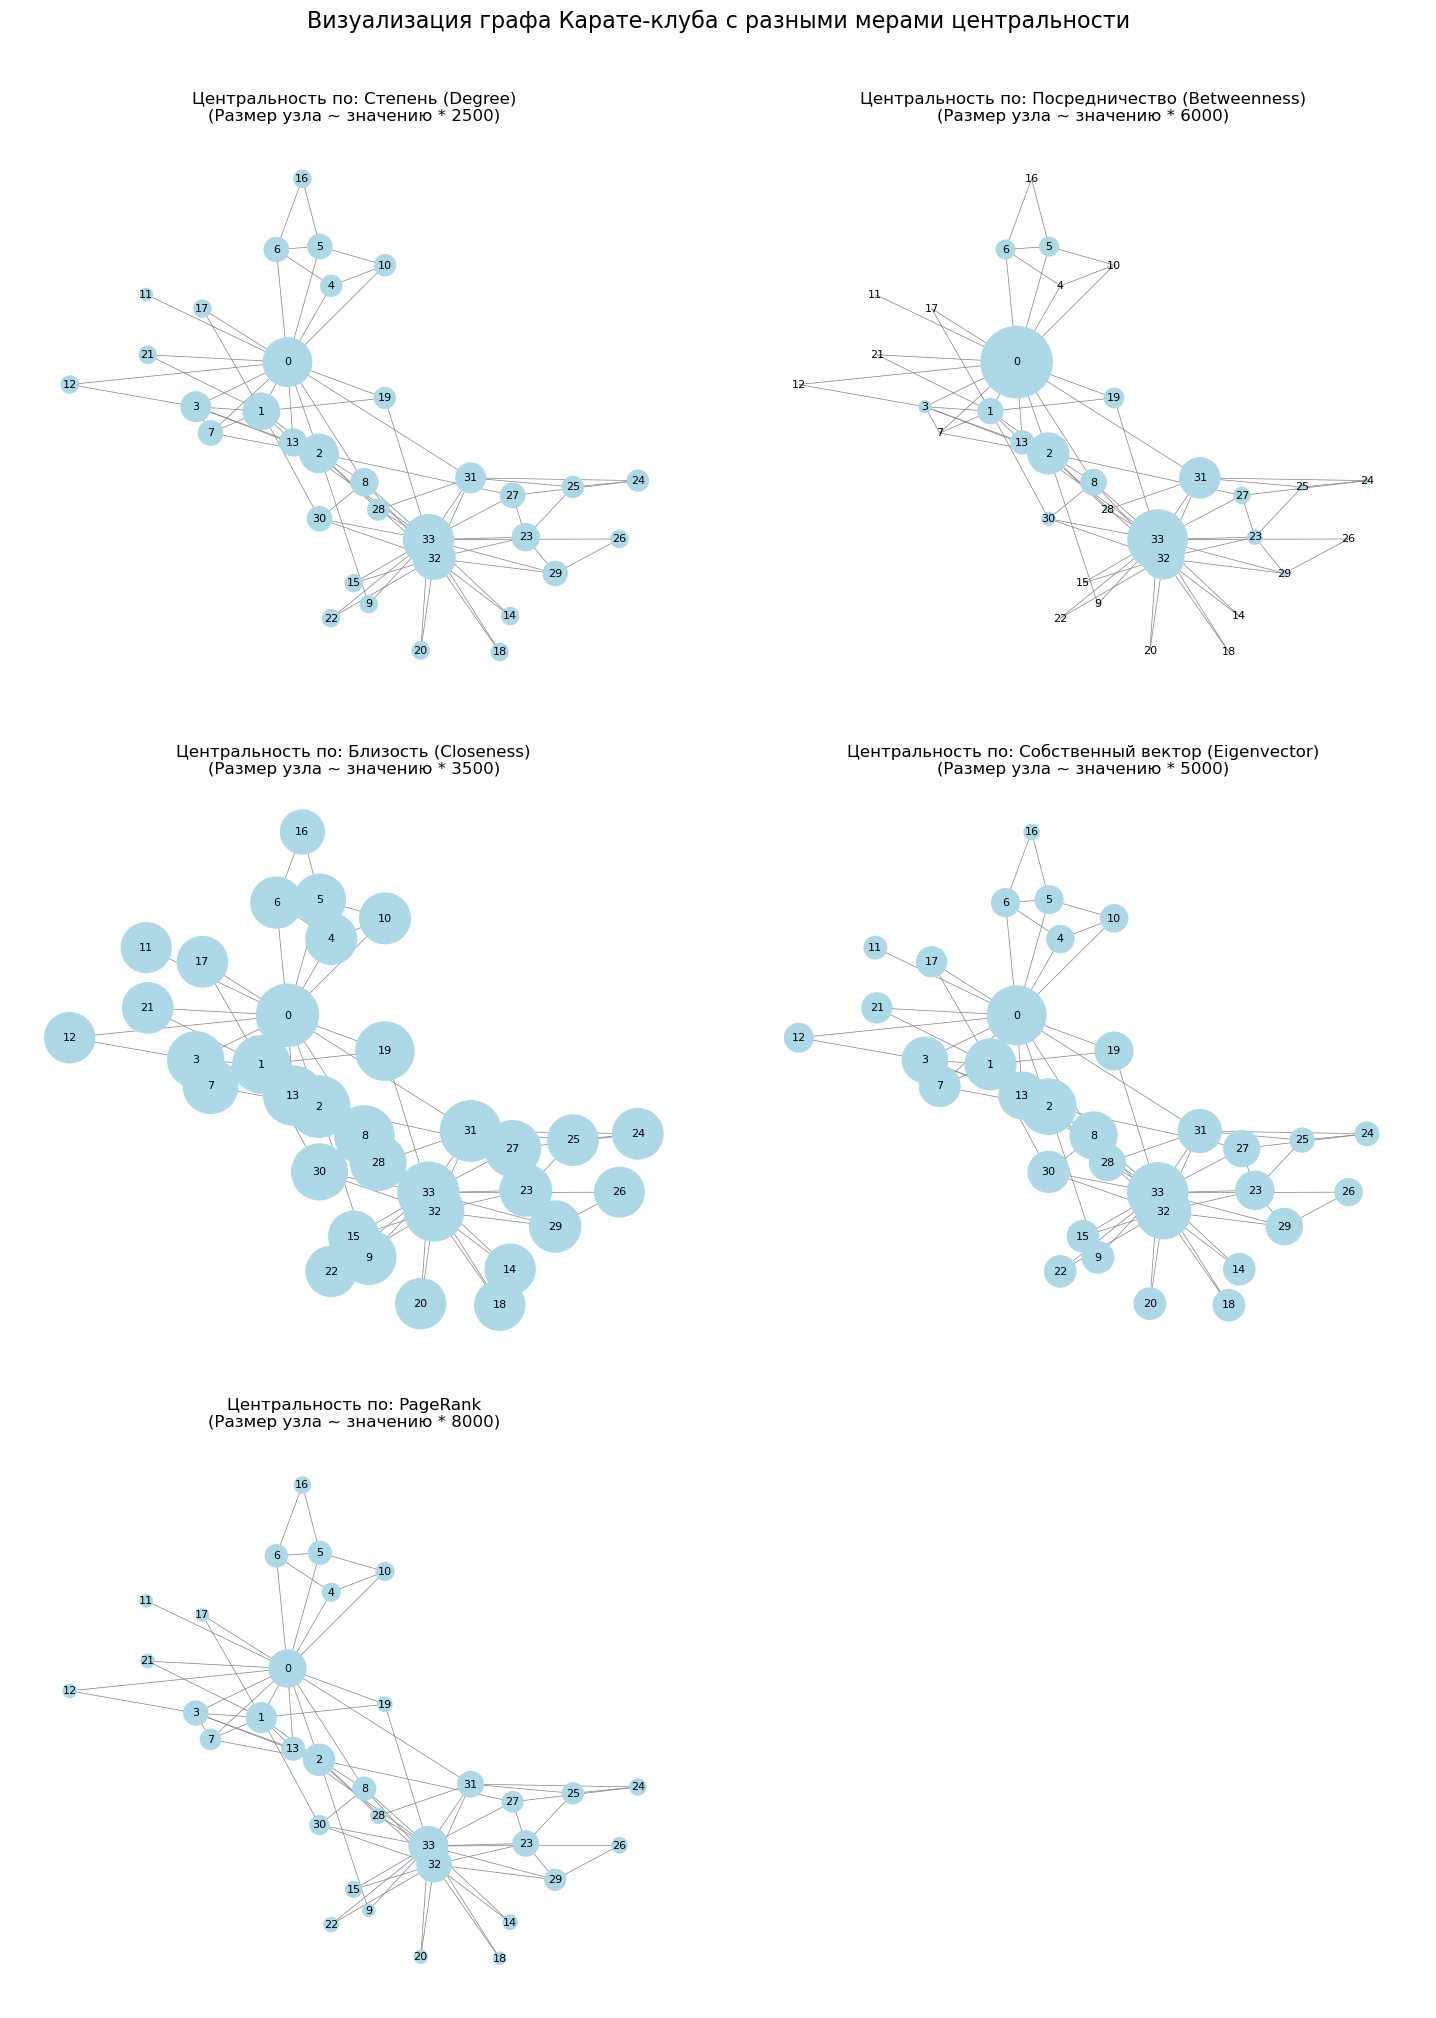

In [17]:
# --- Шаг 4: Визуализация ---

# Определяем сетку для графиков (3x2, т.к. 5 графиков)
fig, axes = plt.subplots(3, 2, figsize=(15, 20))
axes = axes.flatten() # Превращаем массив осей в одномерный для удобства

# Коэффициенты масштабирования (подобраны экспериментально для наглядности)
# Могут требовать подстройки в зависимости от ваших настроек matplotlib
scaling_factors = {
    'Степень (Degree)': 2500,
    'Посредничество (Betweenness)': 6000,
    'Близость (Closeness)': 3500,
    'Собственный вектор (Eigenvector)': 5000,
    'PageRank': 8000
}

node_list = list(G.nodes()) # Фиксируем порядок узлов

for i, (centrality, name) in enumerate(zip(centralities, centrality_names)):
    ax = axes[i]

    # Получаем значения центральности в правильном порядке
    values = [centrality[node] for node in node_list]

    # Масштабируем значения для размеров узлов
    scale = scaling_factors[name]
    node_sizes = [value * scale for value in values]

    # Рисуем граф на соответствующей оси
    nx.draw(
        G,
        pos,
        ax=ax,
        with_labels=True,
        node_size=node_sizes,
        node_color='lightblue', # Цвет узлов
        edge_color='gray',       # Цвет ребер
        font_size=8,             # Размер шрифта меток
        width=0.5                # Толщина ребер
    )
    ax.set_title(f"Центральность по: {name}\n(Размер узла ~ значению * {scale:.0f})", fontsize=12)
    ax.set_axis_off() # Отключаем оси координат

# Отключаем оси для последнего, неиспользуемого графика (если сетка 3x2)
if len(centralities) < len(axes):
    axes[-1].set_axis_off()

plt.tight_layout(pad=3.0) # Улучшаем расположение графиков
plt.suptitle("Визуализация графа Карате-клуба с разными мерами центральности", fontsize=16, y=1.02)
plt.show()

<p class="task" id="3"></p>

3\. Исследуйте, как влияют различные значение параметров `alpha` и `personalization` на результат работы алгоритма. Визуализируйте результаты аналогично предыдущим заданиям и прокомментируйте результат.

- [ ] Проверено на семинаре

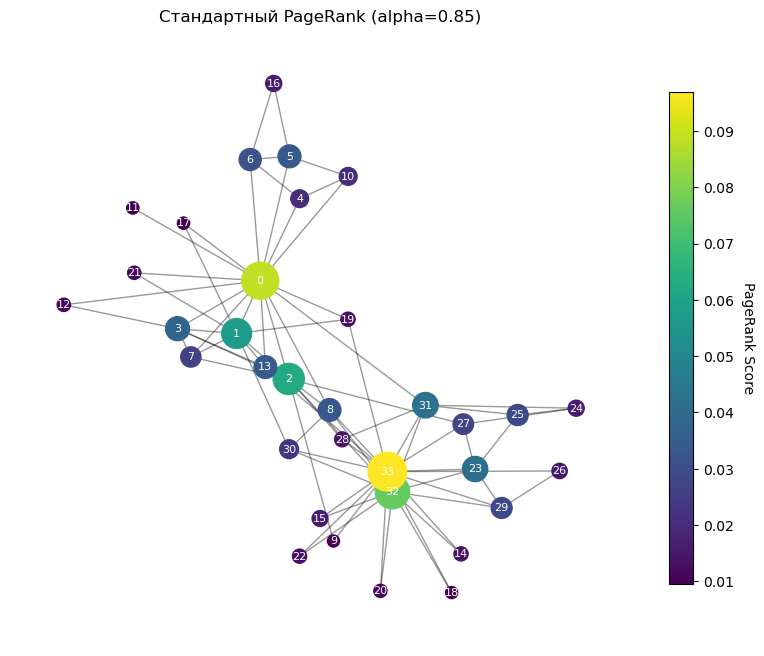

Топ-5 узлов (Стандартный PageRank, alpha=0.85):
[(33, 0.09698041880501741), (0, 0.08850807396280012), (32, 0.07592643687005646), (2, 0.06276686454603017), (1, 0.057414840497110056)]
------------------------------


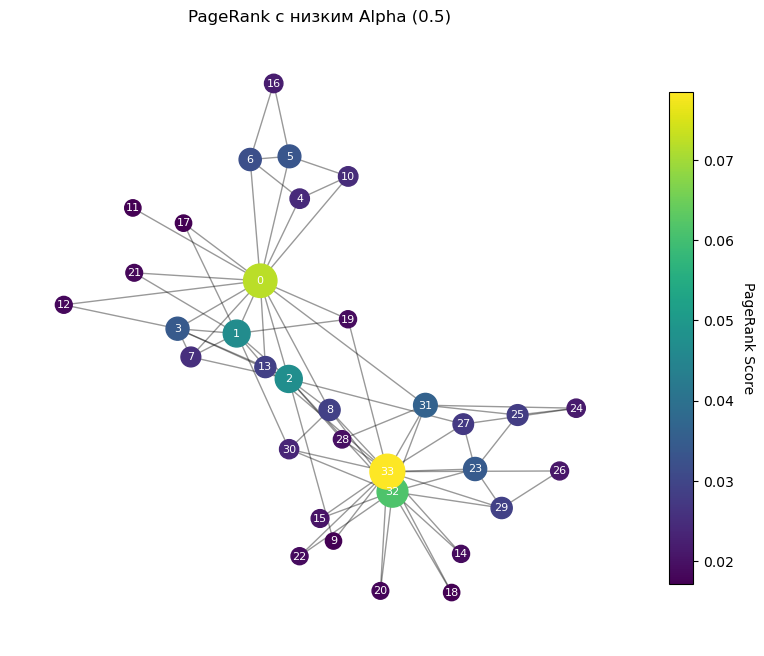

Топ-5 узлов (PageRank, alpha=0.5):
[(33, 0.07856250103692017), (0, 0.07212698693336017), (32, 0.06138727987986935), (2, 0.04718698262939676), (1, 0.04672101546530401)]
------------------------------


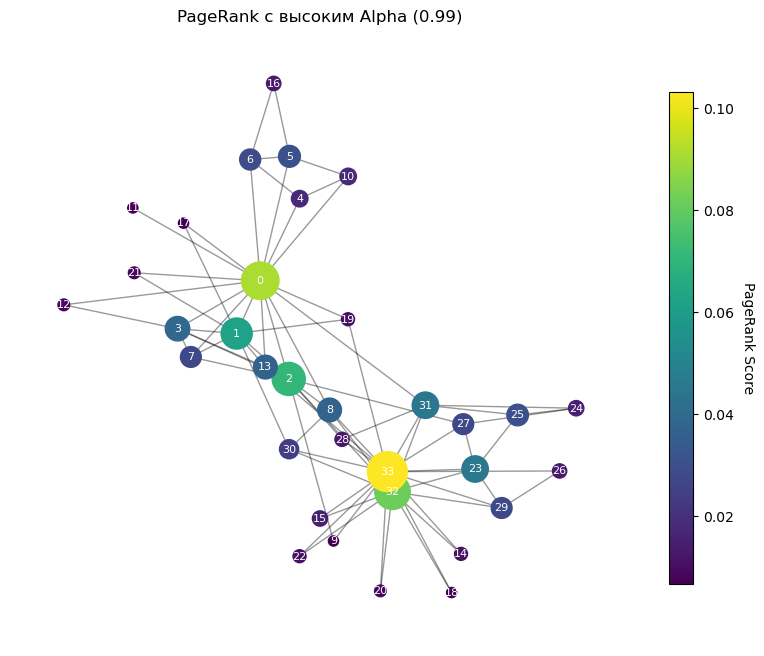

Топ-5 узлов (PageRank, alpha=0.99):
[(33, 0.10325746237154175), (0, 0.09102679490192198), (32, 0.08166400989627112), (2, 0.07080518278601511), (1, 0.06242456115555646)]
------------------------------


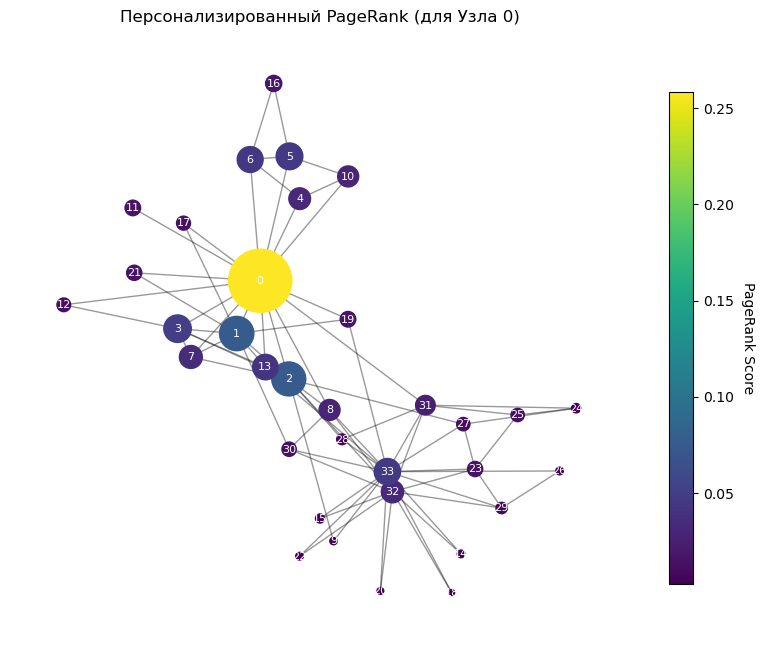

Топ-5 узлов (Персонализированный PageRank для Узла 0):
[(0, 0.2586814904840389), (1, 0.07618884833001639), (2, 0.07488591193830409), (3, 0.048920593377997826), (5, 0.04621087522084753)]
------------------------------


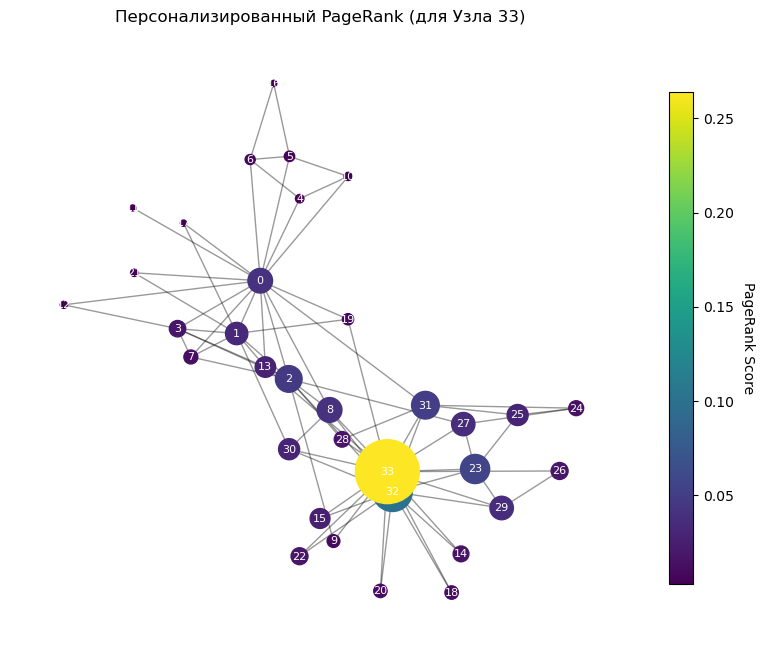

Топ-5 узлов (Персонализированный PageRank для Узла 33):
[(33, 0.2642689336477633), (32, 0.10128870531039887), (23, 0.054953497107141445), (31, 0.04949307179055886), (2, 0.04595254874578094)]
------------------------------


In [ ]:
def plot_pagerank(G, pos, pr_scores, title, node_size_factor=8000):
    """Визуализирует граф, раскрашивая узлы и изменяя их размер в соответствии с PageRank."""
    nodes = G.nodes()
    # Цвета узлов на основе их PageRank
    node_colors = [pr_scores.get(node, 0) for node in nodes]
    # Размеры узлов на основе их PageRank
    node_sizes = [pr_scores.get(node, 0) * node_size_factor for node in nodes]

    # Создаем фигуру и оси ЯВНО
    fig, ax = plt.subplots(figsize=(10, 8)) # Используем subplots для получения ax
    cmap = plt.cm.viridis # Или plt.cm.plasma, plt.cm.coolwarm и т.д.

    # Рисуем ребра, УКАЗЫВАЯ оси ax
    nx.draw_networkx_edges(G, pos, alpha=0.4, ax=ax)
    # Рисуем узлы, УКАЗЫВАЯ оси ax
    nodes_plot = nx.draw_networkx_nodes(G, pos, node_color=node_colors, cmap=cmap, node_size=node_sizes, ax=ax)
    # Добавляем подписи к узлам, УКАЗЫВАЯ оси ax
    nx.draw_networkx_labels(G, pos, font_size=8, font_color='white', ax=ax)

    # Добавляем цветовую шкалу (colorbar)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors)))
    sm.set_array([])
    # УКАЗЫВАЕМ оси ax для colorbar
    cbar = plt.colorbar(sm, shrink=0.8, ax=ax)
    cbar.set_label('PageRank Score', rotation=270, labelpad=15) # Подпись шкалы

    ax.set_title(title) # Устанавливаем заголовок для осей ax
    ax.axis('off') # Отключаем оси для ax
    plt.show() # Показать график

# --- Теперь остальной код должен работать ---

# Рассчитаем PageRank по умолчанию для сравнения
pr_default = nx.pagerank(G, alpha=0.85)
plot_pagerank(G, pos, pr_default, 'Стандартный PageRank (alpha=0.85)')

# Выведем топ-5 узлов для стандартного случая
print("Топ-5 узлов (Стандартный PageRank, alpha=0.85):")
print(sorted(pr_default.items(), key=lambda item: item[1], reverse=True)[:5])
print("-" * 30)

# --- Изменение Alpha ---

# Низкий Alpha
alpha_low = 0.5
pr_alpha_low = nx.pagerank(G, alpha=alpha_low)
plot_pagerank(G, pos, pr_alpha_low, f'PageRank с низким Alpha ({alpha_low})')
print(f"Топ-5 узлов (PageRank, alpha={alpha_low}):")
print(sorted(pr_alpha_low.items(), key=lambda item: item[1], reverse=True)[:5])
print("-" * 30)

# Высокий Alpha
alpha_high = 0.99
pr_alpha_high = nx.pagerank(G, alpha=alpha_high)
plot_pagerank(G, pos, pr_alpha_high, f'PageRank с высоким Alpha ({alpha_high})')
print(f"Топ-5 узлов (PageRank, alpha={alpha_high}):")
print(sorted(pr_alpha_high.items(), key=lambda item: item[1], reverse=True)[:5])
print("-" * 30)


# --- Изменение Personalization ---
# Примечание: здесь мы используем стандартный alpha=0.85, но можно комбинировать изменения.

# Персонализация для Узла 0 (Инструктор)
pers_node0 = {node: 0 for node in G.nodes()} # Создаем словарь с нулями для всех узлов
pers_node0[0] = 1.0 # Весь вес телепортации отдаем узлу 0
pr_pers0 = nx.pagerank(G, alpha=0.85, personalization=pers_node0)
plot_pagerank(G, pos, pr_pers0, 'Персонализированный PageRank (для Узла 0)')
print("Топ-5 узлов (Персонализированный PageRank для Узла 0):")
print(sorted(pr_pers0.items(), key=lambda item: item[1], reverse=True)[:5])
print("-" * 30)

# Персонализация для Узла 33 (Президент/Администратор)
pers_node33 = {node: 0 for node in G.nodes()} # Создаем словарь с нулями
pers_node33[33] = 1.0 # Весь вес телепортации отдаем узлу 33
pr_pers33 = nx.pagerank(G, alpha=0.85, personalization=pers_node33)
plot_pagerank(G, pos, pr_pers33, 'Персонализированный PageRank (для Узла 33)')
print("Топ-5 узлов (Персонализированный PageRank для Узла 33):")
print(sorted(pr_pers33.items(), key=lambda item: item[1], reverse=True)[:5])
print("-" * 30)

<p class="task" id="4"></p>

4\. Реализуйте алгоритм PageRank с параметром затухания $\alpha=0.9$.

Загрузите граф карате-клуба и сделайте его ориентированным. Найдите стохастическую матрицу переходов $\mathbf{P}$.

$$\mathbf{P}=\mathbf{D}^{-1}\mathbf{A}$$

Модифицируйте матрицу $\mathbf{P}$:

$$\mathbf{P}' = \alpha \mathbf{P} + (1-\alpha)\frac{1}{n}\mathbf{E}$$
$$\mathbf{M}=(\mathbf{P}')^{\top}$$

где $\mathbf{E}$ - матрица размера `NxN`, состоящая из единиц.


Инициализируйте вектор $\mathbf{p}^{0}$ значениями $\frac{1}{N}$ и получите вектор $\mathbf{p}^\infty = \mathbf{pr}^{iter}$, используя итеративную процедуру

$$\mathbf{p}^{t+1}=\mathbf{M}\mathbf{p}^t$$

Процесс заканчивается, когда $||\mathbf{p}^{t+1} - \mathbf{p}^{t}|| < \epsilon $

Выведите полученный вектор стационарного состояния на экран.
Вызовите `nx.pagerank` с соответствующими параметрами и докажите, что полученные векторы совпадают.

- [ ] Проверено на семинаре

In [21]:
G_undirected = nx.karate_club_graph()

G = G_undirected.to_directed()

n = G.number_of_nodes()

alpha = 0.9
epsilon = 1e-8 

node_list = list(G.nodes())
node_map = {node: i for i, node in enumerate(node_list)} # Отображение узел -> индекс

print(f"Количество узлов (n): {n}")
print(f"Альфа (alpha): {alpha}")
print(f"Допуск (epsilon): {epsilon}")
print("-" * 30)

# --- Шаг 2: Расчет стохастической матрицы переходов P ---

A = nx.to_numpy_array(G, nodelist=node_list)

out_degrees = A.sum(axis=1)

# Создаем матрицу P (пока нулевую)
P = np.zeros((n, n), dtype=float)


for i in range(n):
    if out_degrees[i] > 0:
        P[i, :] = A[i, :] / out_degrees[i]
    # else: P[i, :] остается нулевым, как и инициализировано

print("Матрица смежности A:\n", A)
print("\nИсходящие степени:\n", out_degrees)
print("\nСтохастическая матрица P (до модификации):\n", P)
print("-" * 30)


# --- Шаг 3: Модификация матрицы P и создание M ---

E = np.ones((n, n))

P_prime = alpha * P + (1 - alpha) / n * E

M = P_prime.T

print("Модифицированная матрица P':\n", P_prime)
print("\nПроверка сумм по строкам P' (должны быть ~1):\n", P_prime.sum(axis=1))
print("\nИтоговая матрица M = (P')^T:\n", M)
print("\nПроверка сумм по столбцам M (должны быть ~1):\n", M.sum(axis=0))
print("-" * 30)

# --- Шаг 4: Итеративная процедура ---

# Инициализируем вектор PageRank p^0
p_t = np.ones(n) / n

iterations = 0
max_iterations = 1000 # Предохранитель от бесконечного цикла

while iterations < max_iterations:
    iterations += 1
    p_t_plus_1 = M @ p_t # p^(t+1) = M * p^t

    # Проверка сходимости: норма L1 разницы векторов
    diff = np.linalg.norm(p_t_plus_1 - p_t, ord=1)

    # Обновляем вектор
    p_t = p_t_plus_1

    if diff < epsilon:
        print(f"Сходимость достигнута за {iterations} итераций.")
        break
else: # Если цикл завершился по max_iterations
    print(f"Внимание: Достигнуто максимальное количество итераций ({max_iterations}) без сходимости по epsilon={epsilon}.")


pr_manual = p_t

print("\nВектор PageRank (ручной расчет):\n", pr_manual)
print(f"Сумма элементов вектора (должна быть ~1): {pr_manual.sum()}")
print("-" * 30)

# --- Шаг 5: Сравнение с nx.pagerank ---

pr_nx_dict = nx.pagerank(G, alpha=alpha, tol=epsilon) 

pr_nx = np.array([pr_nx_dict[node] for node in node_list])

print("Вектор PageRank (NetworkX):\n", pr_nx)
print(f"Сумма элементов вектора (должна быть ~1): {pr_nx.sum()}")
print("-" * 30)

# --- Шаг 6: Проверка совпадения ---

are_close = np.allclose(pr_manual, pr_nx, atol=epsilon*10) # Увеличим допуск для сравнения

print(f"Совпадают ли векторы (с допуском {epsilon*10:.1e})? {are_close}")

if not are_close:
    print("\nВекторы не совпадают достаточно близко. Возможные причины:")
    print("- Различия в обработке 'висячих узлов' (хотя формула P' должна это стандартизировать)")
    print("- Различия в критериях остановки итераций")
    print("- Численные погрешности")
    print("Разница между векторами (L1 норма):", np.linalg.norm(pr_manual - pr_nx, ord=1))

Количество узлов (n): 34
Альфа (alpha): 0.9
Допуск (epsilon): 1e-08
------------------------------
Матрица смежности A:
 [[0. 4. 5. ... 2. 0. 0.]
 [4. 0. 6. ... 0. 0. 0.]
 [5. 6. 0. ... 0. 2. 0.]
 ...
 [2. 0. 0. ... 0. 4. 4.]
 [0. 0. 2. ... 4. 0. 5.]
 [0. 0. 0. ... 4. 5. 0.]]

Исходящие степени:
 [42. 29. 33. 18.  8. 14. 13. 13. 17.  3.  8.  3.  4. 17.  5.  7.  6.  3.
  3.  5.  4.  4.  5. 21.  7. 14.  6. 13.  6. 13. 11. 21. 38. 48.]

Стохастическая матрица P (до модификации):
 [[0.         0.0952381  0.11904762 ... 0.04761905 0.         0.        ]
 [0.13793103 0.         0.20689655 ... 0.         0.         0.        ]
 [0.15151515 0.18181818 0.         ... 0.         0.06060606 0.        ]
 ...
 [0.0952381  0.         0.         ... 0.         0.19047619 0.19047619]
 [0.         0.         0.05263158 ... 0.10526316 0.         0.13157895]
 [0.         0.         0.         ... 0.08333333 0.10416667 0.        ]]
------------------------------
Модифицированная матрица P':
 [[0.00294118 

<p class="task" id="5"></p>

5\. Вычислите коэффициенты PageRank при помощи задачи нахождения собственного вектора матрицы $\mathbf{M}$ $\mathbf{pr}^{eig}$, соответствующего собственному числу 1.

Покажите, что $\mathbf{pr}^{eig}$ и $\mathbf{pr}^{iter}$ оба являются с.в. матрицы $\mathbf{M}$.

- [ ] Проверено на семинаре

In [22]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt # Понадобится, если захотим визуализировать

G_undirected = nx.karate_club_graph()
G = G_undirected.to_directed()
n = G.number_of_nodes()
alpha = 0.9
epsilon = 1e-8
node_list = list(G.nodes())
node_map = {node: i for i, node in enumerate(node_list)}

A = nx.to_numpy_array(G, nodelist=node_list)
out_degrees = A.sum(axis=1)
P = np.zeros((n, n), dtype=float)
for i in range(n):
    if out_degrees[i] > 0:
        P[i, :] = A[i, :] / out_degrees[i]

E = np.ones((n, n))
P_prime = alpha * P + (1 - alpha) / n * E
M = P_prime.T

p_t = np.ones(n) / n
iterations = 0
max_iterations = 1000
while iterations < max_iterations:
    iterations += 1
    p_t_plus_1 = M @ p_t
    diff = np.linalg.norm(p_t_plus_1 - p_t, ord=1)
    p_t = p_t_plus_1
    if diff < epsilon:
        break
pr_iter = p_t # Переименовали pr_manual в pr_iter

# --- Шаг 5: Вычисление собственного вектора ---

print("\n--- Шаг 5: Вычисление через собственный вектор ---")

eigenvalues, eigenvectors = np.linalg.eig(M)

idx_lambda_1 = np.argmin(np.abs(eigenvalues - 1.0))

print(f"Найденное собственное значение, близкое к 1: {eigenvalues[idx_lambda_1]:.10f}")

# Получаем соответствующий собственный вектор (это столбец в матрице eigenvectors)
pr_eig_raw = eigenvectors[:, idx_lambda_1]

pr_eig_real = np.real(pr_eig_raw)

pr_eig_real_positive = np.maximum(pr_eig_real, 0) # Убираем возможные очень маленькие отрицательные значения из-за погрешностей
pr_eig = pr_eig_real_positive / pr_eig_real_positive.sum()

print("\nВектор PageRank (через собственный вектор):\n", pr_eig)
print(f"Сумма элементов вектора (должна быть ~1): {pr_eig.sum()}")
print("-" * 30)

# --- Сравнение pr_iter и pr_eig ---
are_close_eigen_iter = np.allclose(pr_iter, pr_eig, atol=epsilon*10)
print(f"Совпадают ли векторы pr_iter и pr_eig (с допуском {epsilon*10:.1e})? {are_close_eigen_iter}")
if not are_close_eigen_iter:
    print("Разница (L1 норма):", np.linalg.norm(pr_iter - pr_eig, ord=1))
print("-" * 30)

# --- Проверка, что оба вектора являются собственными векторами для lambda=1 ---

print("Проверка, являются ли векторы собственными для M с lambda=1:")

M_times_pr_iter = M @ pr_iter
# Сравниваем M @ pr_iter с 1 * pr_iter
is_eigenvector_iter = np.allclose(M_times_pr_iter, pr_iter, atol=epsilon)
print(f"Является ли pr_iter собственным вектором (M@p == p)? {is_eigenvector_iter}")
if not is_eigenvector_iter:
    print("  Разница M@pr_iter - pr_iter (L1 норма):", np.linalg.norm(M_times_pr_iter - pr_iter, ord=1))

M_times_pr_eig = M @ pr_eig
# Сравниваем M @ pr_eig с 1 * pr_eig
is_eigenvector_eig = np.allclose(M_times_pr_eig, pr_eig, atol=epsilon)
print(f"Является ли pr_eig собственным вектором (M@p == p)? {is_eigenvector_eig}")
if not is_eigenvector_eig:
    print("  Разница M@pr_eig - pr_eig (L1 норма):", np.linalg.norm(M_times_pr_eig - pr_eig, ord=1))

print("-" * 30)


--- Шаг 5: Вычисление через собственный вектор ---
Найденное собственное значение, близкое к 1: 1.0000000000+0.0000000000j

Вектор PageRank (через собственный вектор):
 [0.08988771 0.05913748 0.06546514 0.03776398 0.01970143 0.03322244
 0.03092853 0.02694096 0.03436443 0.00844129 0.01984993 0.00871967
 0.01053194 0.03448906 0.01218335 0.01589805 0.01577198 0.00862881
 0.00849837 0.01232146 0.010326   0.01046411 0.01219821 0.04234102
 0.01604281 0.02902514 0.01444809 0.02738781 0.0139083  0.02813855
 0.02316919 0.04295198 0.07779414 0.09905866]
Сумма элементов вектора (должна быть ~1): 1.0
------------------------------
Совпадают ли векторы pr_iter и pr_eig (с допуском 1.0e-07)? True
------------------------------
Проверка, являются ли векторы собственными для M с lambda=1:
Является ли pr_iter собственным вектором (M@p == p)? True
Является ли pr_eig собственным вектором (M@p == p)? True
------------------------------
